<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [74]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab → do nothing
    pass

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm

# Load Data
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

In [76]:
from pathlib import Path

dataset_name = "Labeled_Datasets/Ecuador"
file_name = "Ecuador_part_4.gzip.parquet"

# Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    in_colab = True
    print("Running inside Colab. Loading from Google Drive...")

# BGU Slurm Cluster
except ImportError:
    # working directory is: Backbone-Graph/src
    file_path = Path("../data") / dataset_name / file_name
    in_colab = False
    print("Running on Slurm cluster. Loading local file...")


# Load the parquet file
df = pd.read_parquet(file_path)

# for testing
df = df.head(1000).copy() 

Running on Slurm cluster. Loading local file...


In [77]:
# output_path

file_path = Path(file_path)


if in_colab:
  output_folder_path = (file_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / file_path.parent.name / file_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = Path(file_name).stem.split(".")[0] 
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes
  # Example: "../results/Labeled_Datasets/Ecuador/Ecuador_part_3/"


output_folder_path.mkdir(parents=True, exist_ok=True) # Creates the parent directory if needed

print(output_folder_path)

../results/Labeled_Datasets/Ecuador/Ecuador_part_4


In [78]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
150000,3430e7d94eb30635b0438dc41b2a9eaf895f897492,ÚLTIMAS ENTRADAS BOX a #NERVO en #GUAYAQUIL ha...,98e641fa834c638dc2660bf4146cd6ff5a97387b0f,es,None,None,2014-01-10 14:58:48,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,120,2012-03-11,True,e499f3c7fb536a9bcd4ba8fb90f873446a26cb9a64,cab1ea0e3bb16854d6659a0d24291add6900a28e14,"[NERVO, GUAYAQUIL]",[https://300b75d6b9c57861982f0aed6a4e82c9c89bb...,"[e499f3c7fb536a9bcd4ba8fb90f873446a26cb9a64, 6...",True
150001,800a113993c1312f55f95d55b864cead455130509a,Presidente Rafael Correa arribó a Guayaquil,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2014-01-10 15:08:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,True,d77588c443644c33536cb68bb7610be2626b47b9b9,d2a25b31d1f80232461e84078fcccf9f71a7c07bb6,[],[],[d77588c443644c33536cb68bb7610be2626b47b9b9],False
150002,66ea22d7cff2748968bea3d4985fd002a5e8196b66,#Guayaquil Current Conditions: (as of 09:00)Nu...,98e641fa834c638dc2660bf4146cd6ff5a97387b0f,en,None,None,2014-01-10 15:16:53,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,120,2012-03-11,True,9a5e104e8f560683d04189cb4ab0ffc3764a5c210a,d8a6dbac3a3c394e01ec882cb032397b8d21584b4a,[Guayaquil],[],[9a5e104e8f560683d04189cb4ab0ffc3764a5c210a],True
150003,b9dc9cf6defad782d91bf41354002ae6343597462a,"En breve, el presidente #Correa inaugurará el ...",98e641fa834c638dc2660bf4146cd6ff5a97387b0f,es,None,None,2014-01-10 15:16:54,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,120,2012-03-11,True,73bb9a9ab693e41a66bb0fe5ad9e8a9b46236a563c,b847e886ec1e796e0fb957bf1cc5f022d6f925a103,"[Correa, Guayaquil]",[],"[73bb9a9ab693e41a66bb0fe5ad9e8a9b46236a563c, 1...",True
150004,02510eefc7c906ab04db8da6eed5014422439781bc,Creo que necesito lentes :(,2727201c363b6fc4afe259ba4094ae0c49cb4df224,es,None,None,2014-01-10 15:34:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[],[],[],False


## Dataset Statistics

In [79]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (1000, 19)
df posts with hashtags # shape:          (462, 19)  (46.20%)
df posts with account_mentions @ shape:  (787, 19)  (78.70%)
df posts with urls shape:                (566, 19)  (56.60%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                 

# Clean Text

In [80]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [81]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [82]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

# Translation to English

In [83]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [84]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [85]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=400, batch_size=16)

Using device: cuda


Device set to use cuda


In [86]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "post_text",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [87]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.join(translated_df)

df shape: (1000, 20)


Translating by language:   0%|          | 0/11 [00:00<?, ?it/s]

2 posts: cat_Latn → eng_Latn
151 posts: eng_Latn → spa_Latn → eng_Latn
2 posts: ita_Latn → eng_Latn
2 posts: lt → eng_Latn
1 posts: pol_Latn → eng_Latn
22 posts: por_Latn → eng_Latn
1 posts: ro → eng_Latn
1 posts: rus_Cyrl → eng_Latn
799 posts: spa_Latn → eng_Latn
1 posts: tgl_Latn → eng_Latn
13 posts: und → eng_Latn


In [88]:
df[["post_text", "post_language", "translated_post"]].head()

,post_text,post_language,translated_post
150000,ÚLTIMAS ENTRADAS BOX a #NERVO en #GUAYAQUIL ha...,spa_Latn,Last days BOX entries to #NERVO on #GUAYAQUIL ...
150001,Presidente Rafael Correa arribó a Guayaquil,spa_Latn,President Rafael Correa has arrived in Guayaquil
150002,#Guayaquil Current Conditions: (as of 09:00)Nu...,eng_Latn,#Guayaquil Current conditions: (from 09:00) Cl...
150003,"En breve, el presidente #Correa inaugurará el ...",spa_Latn,"Soon, President #Correa will inaugurate the re..."
150004,Creo que necesito lentes :(,spa_Latn,I think I need glasses:


In [89]:
print(df['post_language'].value_counts())

post_language
spa_Latn    799
eng_Latn    151
por_Latn     22
und          13
ita_Latn      2
cat_Latn      2
lt            2
tgl_Latn      1
pol_Latn      1
rus_Cyrl      1
ro            1
Name: count, dtype: int64


# Remove Engllish Stopwords

In [90]:
from nltk.corpus import stopwords
import nltk

In [91]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [92]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [93]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
150000,ÚLTIMAS ENTRADAS BOX a #NERVO en #GUAYAQUIL ha...,últimas entradas box hashtag_nervo en hashtag_...
150001,Presidente Rafael Correa arribó a Guayaquil,presidente rafael correa arribó guayaquil
150002,#Guayaquil Current Conditions: (as of 09:00)Nu...,hashtag_guayaquil current conditions: (as 09:0...
150003,"En breve, el presidente #Correa inaugurará el ...","en breve, el presidente hashtag_correa inaugur..."
150004,Creo que necesito lentes :(,creo que necesito lentes :(
150005,Old School Villains https://0ec8311ed4a86c40d8...,old school villains url_0ec8311ed4a86c40d8e91a...
150006,Daniel Saab - Concejal por Samborondon;sirviò ...,daniel saab - concejal por samborondon;sirviò ...
150007,En auditorio se presenta un video del antes y ...,en auditorio se presenta un video del antes de...
150008,Gustavo #Jalkh: La justicia en #Guayaquil no e...,gustavo hashtag_jalkh : la justicia en hashtag...
150009,#Guayaquil Current Conditions: (as of 11:00)Ma...,hashtag_guayaquil current conditions: (as 11:0...


# English Topic Clustering

## Utils


In [94]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        pd.DataFrame: Topic stats with Count, IO_Count, Legitimate_posts.
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              Count=(topic_col_name, "count"),
              IO_Count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["Legitimate_posts"] = topic_stats["Count"] - topic_stats["IO_Count"]
    return topic_stats

In [95]:
def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["IO_Count"]
    legitimate_count = topic_stats["Legitimate_posts"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    plt.title(f"Post Count per Topic, Model name: {model_name}")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()


    # if output_folder_path:
        # plot_file_path = output_folder_path / f"{output_folder_path}_topic_stats.png"
        # plt.savefig(plot_file_path, dpi=300)


    plt.show()

In [96]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [97]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

## BERTopic

In [98]:
def english_BERTopic_modeling(posts_text_lst, embeddings, min_topic_size=10):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    return topics, probs, topic_model


In [99]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings)

df["BERTopic_topic"] = BERTopic_topic

BERTopic_model.get_topic_info()

2025-11-26 13:33:18,705 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-26 13:33:20,466 - BERTopic - Dimensionality - Completed ✓
2025-11-26 13:33:20,467 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-26 13:33:20,493 - BERTopic - Cluster - Completed ✓
2025-11-26 13:33:20,495 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-26 13:33:20,531 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,224,-1_en_de_hashtagguayaquil_el,"[en, de, hashtagguayaquil, el, la, del, por, h...",[hashtag_onaire la hashtag_quintasinfonia en h...
1,0,129,0_que_la_mi_de,"[que, la, mi, de, es, un, el, los, pero, ser]",[la diferencia que le tenia mi papá mi mamá er...
2,1,91,1_que_los_si_un,"[que, los, si, un, de, en, te, la, su, por]",[-¿qué te pasa? -cualquier persona que tenga d...
3,2,56,2_hashtagguayaquil_de_en_la,"[hashtagguayaquil, de, en, la, va, del, guayaq...",[últimas entradas box hashtag_nervo en hashtag...
4,3,55,3_hashtagquito_hashtagcuenca_hashtagambato_de,"[hashtagquito, hashtagcuenca, hashtagambato, d...","[si necesitas comprar vender escríbenos,alguie..."
5,4,53,4_que_mentiond7b4b0e86992768572e6c3dcafcfea323...,"[que, mentiond7b4b0e86992768572e6c3dcafcfea323...","[actualmente eso esta sobrevalorado, por eso e..."
6,5,51,5_hashtagecuador_ecuador_de_en,"[hashtagecuador, ecuador, de, en, el, hashtage...",[grupo en facebook: anuncios compra venta en e...
7,6,44,6_mentione504afaba4ce69a3ae0ddf083ed8fff1f10f4...,[mentione504afaba4ce69a3ae0ddf083ed8fff1f10f40...,[mention_84e8c6be7c36028f5300e9591f696077fd315...
8,7,31,7_followme_yes_thanks_please,"[followme, yes, thanks, please, greetings, nig...",[mention_ab33885a275d29a4e2acd3326b245ab00b024...
9,8,27,8_hashtag7rc_hashtagdespertarpatria_mention208...,"[hashtag7rc, hashtagdespertarpatria, mention20...",[pueden ver en vivo la celebración por los 7 a...


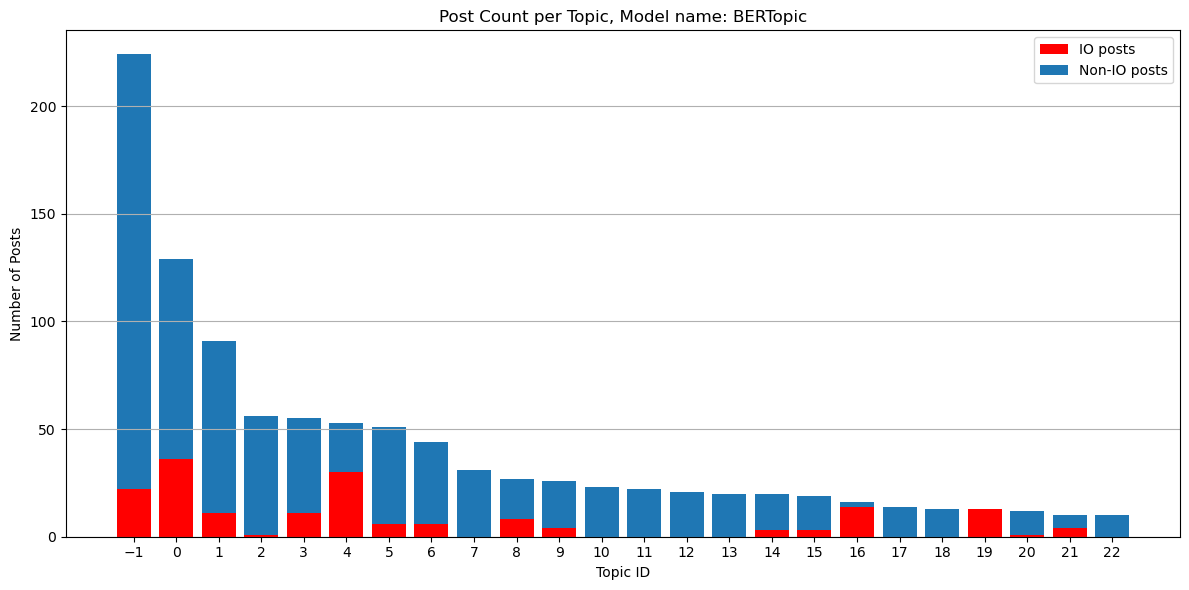

In [100]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

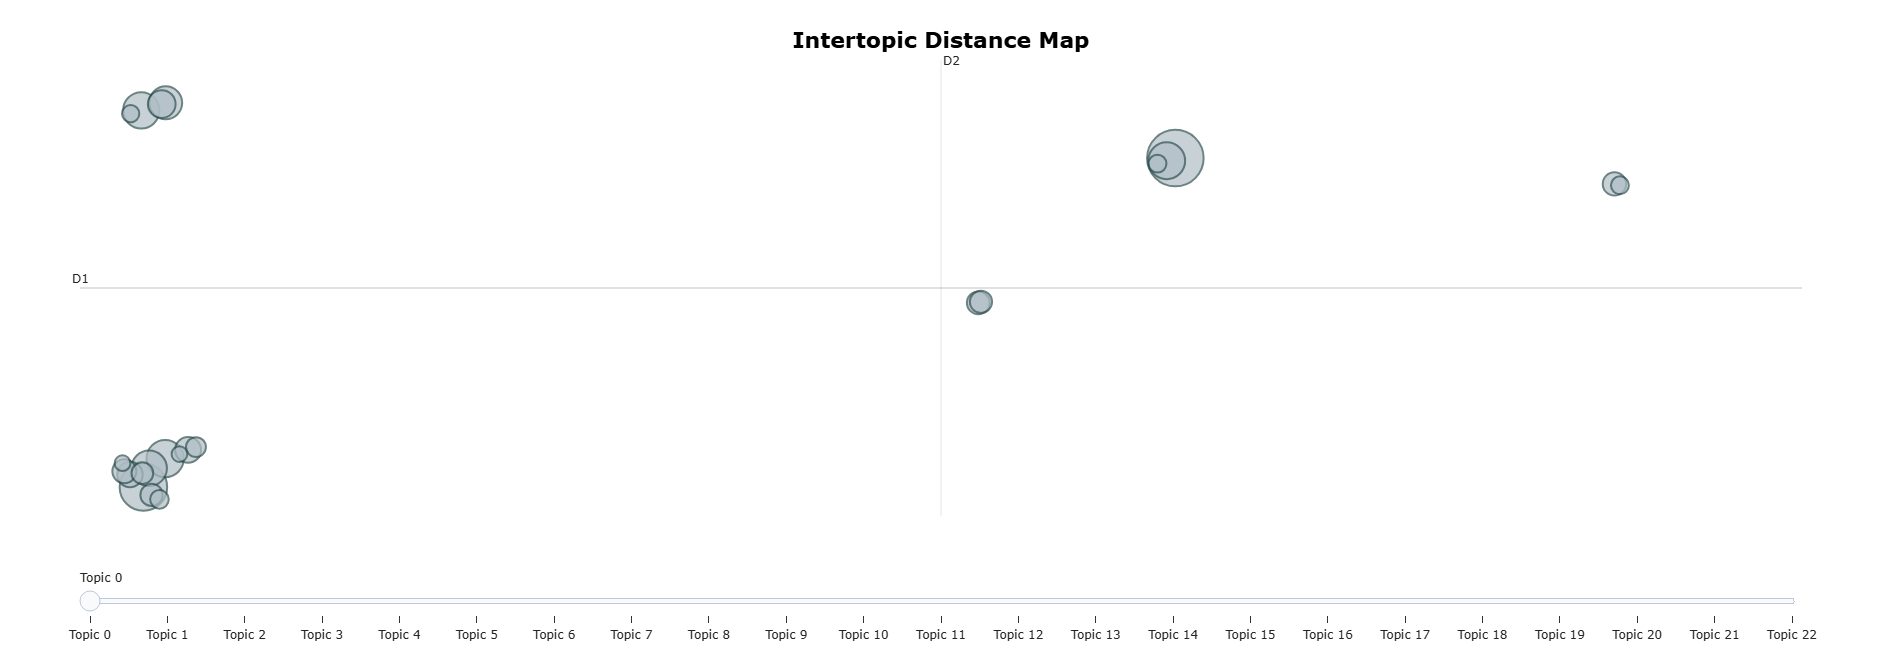

In [101]:
from IPython.display import display

try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # <-- required to show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

## K-Means

In [102]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [103]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Best k: 8


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,translated_post,BERTopic_topic,K_Means_topic
150000,3430e7d94eb30635b0438dc41b2a9eaf895f897492,ÚLTIMAS ENTRADAS BOX a #NERVO en #GUAYAQUIL ha...,98e641fa834c638dc2660bf4146cd6ff5a97387b0f,spa_Latn,None,None,2014-01-10 14:58:48,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,...,e499f3c7fb536a9bcd4ba8fb90f873446a26cb9a64,cab1ea0e3bb16854d6659a0d24291add6900a28e14,"[NERVO, GUAYAQUIL]",[https://300b75d6b9c57861982f0aed6a4e82c9c89bb...,"[e499f3c7fb536a9bcd4ba8fb90f873446a26cb9a64, 6...",True,últimas entradas box hashtag_nervo en hashtag_...,Last days BOX entries to #NERVO on #GUAYAQUIL ...,2,4
150001,800a113993c1312f55f95d55b864cead455130509a,Presidente Rafael Correa arribó a Guayaquil,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,spa_Latn,None,None,2014-01-10 15:08:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,d77588c443644c33536cb68bb7610be2626b47b9b9,d2a25b31d1f80232461e84078fcccf9f71a7c07bb6,[],[],[d77588c443644c33536cb68bb7610be2626b47b9b9],False,presidente rafael correa arribó guayaquil,President Rafael Correa has arrived in Guayaquil,0,0
150002,66ea22d7cff2748968bea3d4985fd002a5e8196b66,#Guayaquil Current Conditions: (as of 09:00)Nu...,98e641fa834c638dc2660bf4146cd6ff5a97387b0f,eng_Latn,None,None,2014-01-10 15:16:53,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,...,9a5e104e8f560683d04189cb4ab0ffc3764a5c210a,d8a6dbac3a3c394e01ec882cb032397b8d21584b4a,[Guayaquil],[],[9a5e104e8f560683d04189cb4ab0ffc3764a5c210a],True,hashtag_guayaquil current conditions: (as 09:0...,#Guayaquil Current conditions: (from 09:00) Cl...,18,2
150003,b9dc9cf6defad782d91bf41354002ae6343597462a,"En breve, el presidente #Correa inaugurará el ...",98e641fa834c638dc2660bf4146cd6ff5a97387b0f,spa_Latn,None,None,2014-01-10 15:16:54,96df181a83328d9a5e08194fbe17f825757bdfbffa,Actualización pendiente...,2306,...,73bb9a9ab693e41a66bb0fe5ad9e8a9b46236a563c,b847e886ec1e796e0fb957bf1cc5f022d6f925a103,"[Correa, Guayaquil]",[],"[73bb9a9ab693e41a66bb0fe5ad9e8a9b46236a563c, 1...",True,"en breve, el presidente hashtag_correa inaugur...","Soon, President #Correa will inaugurate the re...",15,4
150004,02510eefc7c906ab04db8da6eed5014422439781bc,Creo que necesito lentes :(,2727201c363b6fc4afe259ba4094ae0c49cb4df224,spa_Latn,None,None,2014-01-10 15:34:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,None,None,[],[],[],False,creo que necesito lentes :(,I think I need glasses:,0,3


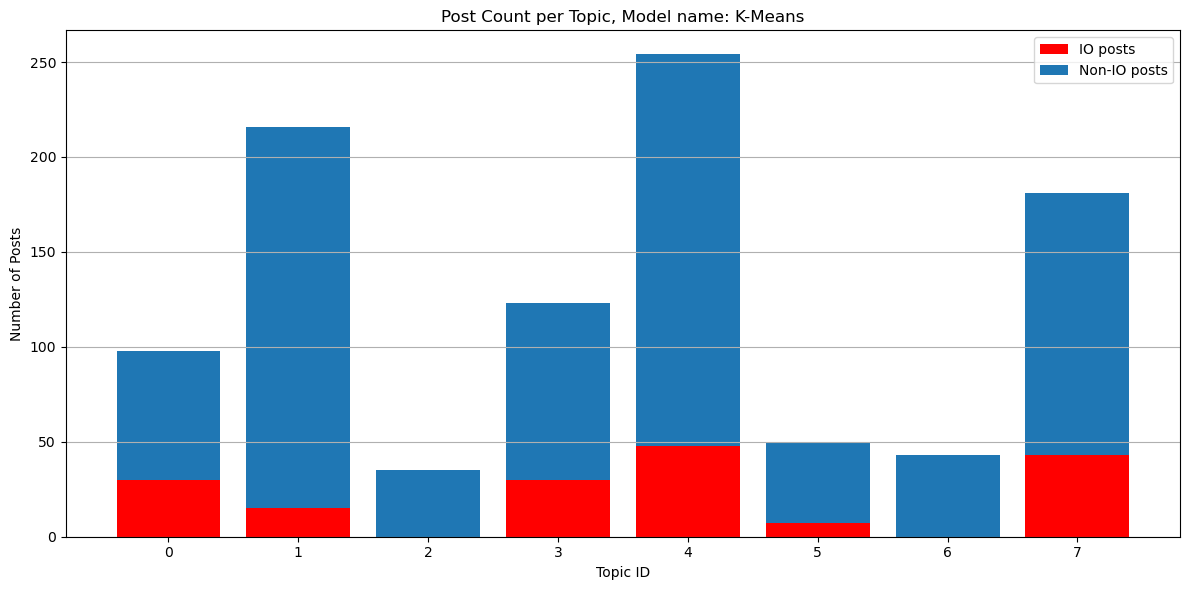

In [104]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

# Named Entity Recognition (NER)

In [105]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [106]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [107]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
150000,últimas entradas box hashtag_nervo en hashtag_...,[guayaquil]
150001,presidente rafael correa arribó guayaquil,"[rafael, rea]"
150002,hashtag_guayaquil current conditions: (as 09:0...,[guayaquil]
150003,"en breve, el presidente hashtag_correa inaugur...",[guayaqu@@]
150006,daniel saab - concejal por samborondon;sirviò ...,"[daniel saab, jal, sambor@@, jal, guayaqu@@]"


# Save to parquet

In [109]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_4/Topic_Ner_Ecuador_part_4.gzip.parquet
